In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

In [9]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [10]:
import urllib.request

homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [11]:
import numpy as np
from PIL import Image

image = np.asarray(Image.open(filepath))
print(image.shape)

(533, 800, 3)


In [12]:
X = image.reshape(-1, 3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

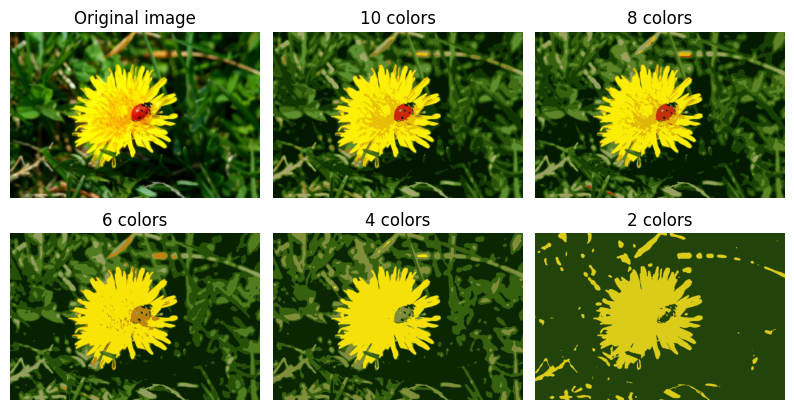

In [13]:
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation_plot', tight_layout=False)
plt.show()

Original size: (800, 533)
Resized shape: (200, 200, 3)


/tmp/ipython-input-3875998734.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
/tmp/ipython-input-3875998734.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
/tmp/ipython-input-3875998734.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labe

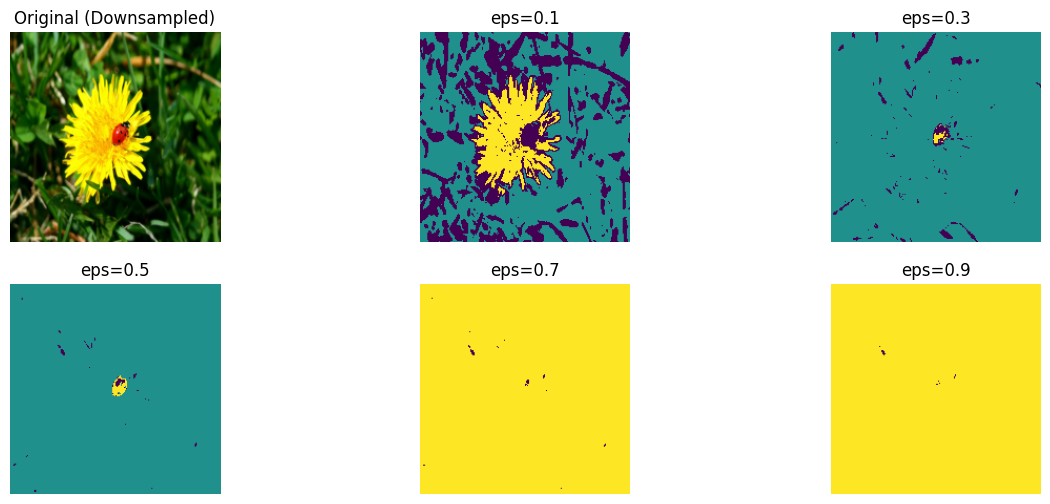

In [28]:
pil_obj = Image.open(filepath).convert('RGB')
print(f"Original size: {pil_obj.size}")

img_small_pil = pil_obj.resize((200, 200))

image_np = np.asarray(img_small_pil)
print(f"Resized shape: {image_np.shape}")

X = image_np.reshape(-1, 3)
X_scaled = StandardScaler().fit_transform(X)

eps_values = [0.1, 0.3, 0.5, 0.7, 0.9]
# , 0.5, 0.7, 0.9
db_segmented_imgs = []

for e in eps_values:
    dbscan = DBSCAN(eps=e, min_samples=60).fit(X_scaled)
    labels = dbscan.labels_
    unique_labels = len(np.unique(labels))

    colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
    db_segmented_imgs.append(colors.reshape(image_np.shape))

plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(image_np)
plt.title("Original (Downsampled)")
plt.axis('off')

for idx, e in enumerate(eps_values):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(db_segmented_imgs[idx])
    plt.title(f"eps={e}")
    plt.axis('off')
plt.show()

Original size: (800, 533)
Resized shape: (100, 100, 3)


/tmp/ipython-input-2037584557.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
/tmp/ipython-input-2037584557.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
/tmp/ipython-input-2037584557.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labe

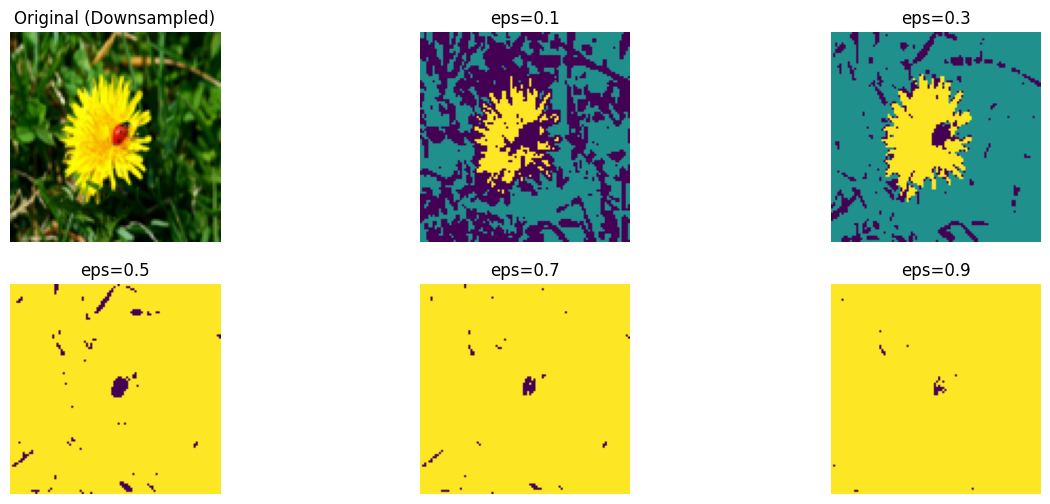

In [29]:
pil_obj = Image.open(filepath).convert('RGB')
print(f"Original size: {pil_obj.size}")

img_small_pil = pil_obj.resize((100, 100))

image_np = np.asarray(img_small_pil)
print(f"Resized shape: {image_np.shape}")

X = image_np.reshape(-1, 3)
X_scaled = StandardScaler().fit_transform(X)

eps_values = [0.1, 0.3, 0.5, 0.7, 0.9]
# , 0.5, 0.7, 0.9
db_segmented_imgs = []

for e in eps_values:
    dbscan = DBSCAN(eps=e, min_samples=60).fit(X_scaled)
    labels = dbscan.labels_
    unique_labels = len(np.unique(labels))

    colors = plt.cm.get_cmap('viridis')( (labels + 1) / (labels.max() + 1) )[:, :3]
    db_segmented_imgs.append(colors.reshape(image_np.shape))

plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(image_np)
plt.title("Original (Downsampled)")
plt.axis('off')

for idx, e in enumerate(eps_values):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(db_segmented_imgs[idx])
    plt.title(f"eps={e}")
    plt.axis('off')
plt.show()

Original size: (800, 533)
Resized shape: (200, 200, 3)


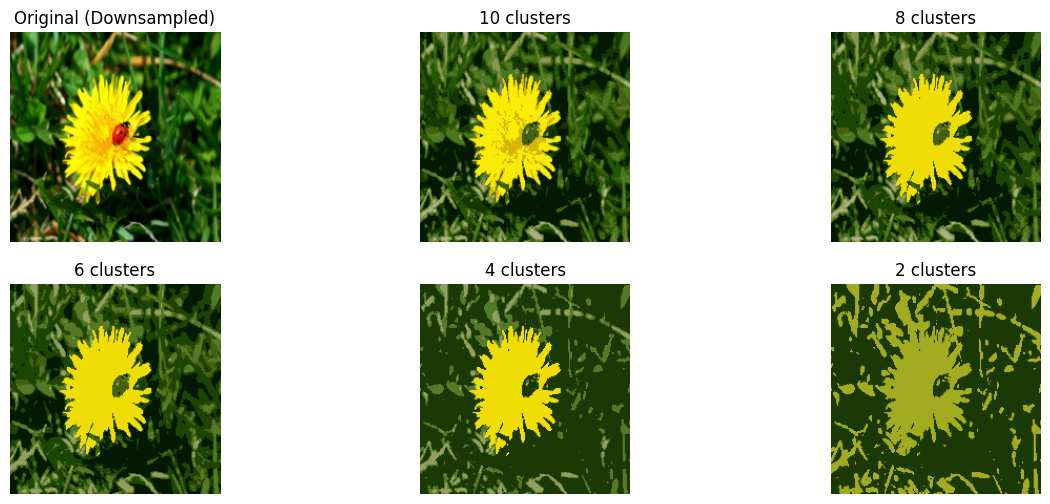

In [30]:
pil_obj = Image.open(filepath).convert('RGB')
print(f"Original size: {pil_obj.size}")

img_small_pil = pil_obj.resize((200, 200))

image_np = np.asarray(img_small_pil)
print(f"Resized shape: {image_np.shape}")

X = image_np.reshape(-1, 3)
X_scaled = StandardScaler().fit_transform(X)

n_colors = (10, 8, 6, 4, 2)
agglo_segmented_imgs = []

for n in n_colors:
    agglo = AgglomerativeClustering(n_clusters=n).fit(X_scaled)
    labels = agglo.labels_

    current_segmented = np.zeros_like(X)
    for cluster_id in range(n):
        mask = (labels == cluster_id)
        current_segmented[mask] = X[mask].mean(axis=0)

    agglo_segmented_imgs.append(current_segmented.reshape(image_np.shape))

plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(image_np)
plt.title("Original (Downsampled)")
plt.axis('off')

for idx, n in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(agglo_segmented_imgs[idx].astype(np.uint8))
    plt.title(f"{n} clusters")
    plt.axis('off')
plt.show()

Original size: (800, 533)
Resized shape: (100, 100, 3)


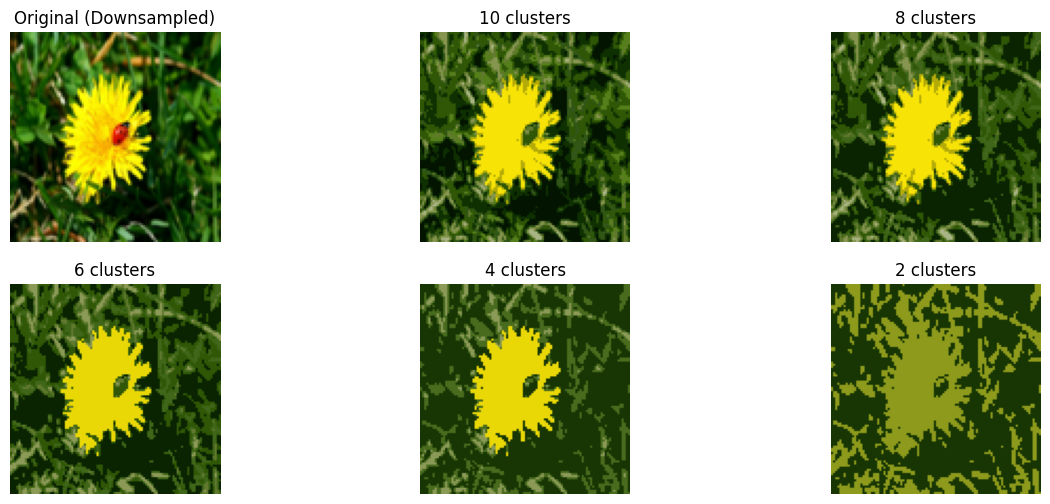

In [27]:
pil_obj = Image.open(filepath).convert('RGB')
print(f"Original size: {pil_obj.size}")

img_small_pil = pil_obj.resize((100, 100))

image_np = np.asarray(img_small_pil)
print(f"Resized shape: {image_np.shape}")

X = image_np.reshape(-1, 3)
X_scaled = StandardScaler().fit_transform(X)

n_colors = (10, 8, 6, 4, 2)
agglo_segmented_imgs = []

for n in n_colors:
    agglo = AgglomerativeClustering(n_clusters=n).fit(X_scaled)
    labels = agglo.labels_

    current_segmented = np.zeros_like(X)
    for cluster_id in range(n):
        mask = (labels == cluster_id)
        current_segmented[mask] = X[mask].mean(axis=0)

    agglo_segmented_imgs.append(current_segmented.reshape(image_np.shape))

plt.figure(figsize=(15, 6))
plt.subplot(2, 3, 1)
plt.imshow(image_np)
plt.title("Original (Downsampled)")
plt.axis('off')

for idx, n in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(agglo_segmented_imgs[idx].astype(np.uint8))
    plt.title(f"{n} clusters")
    plt.axis('off')
plt.show()

I chose Synthetic blobs dataset

In [1]:
from sklearn.datasets import make_blobs

X_blobs, y_blobs = make_blobs(n_samples=1000, centers=4, cluster_std=0.60, random_state=42)

print(f"Shape of X_blobs: {X_blobs.shape}")
print(f"Shape of y_blobs: {y_blobs.shape}")

Shape of X_blobs: (1000, 2)
Shape of y_blobs: (1000,)


## Moon Dataset

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from IPython.display import display

In [6]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

In [7]:
def plot_clustering_comparison(eps, min_samples, n_clusters_kmeans):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = dbscan.fit_predict(X_moons)
    
    kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init=10)
    km_labels = kmeans.fit_predict(X_moons)
    km_centers = kmeans.cluster_centers_

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    unique_labels = set(db_labels)
    colors = plt.cm.get_cmap("Spectral")(np.linspace(0, 1, len(unique_labels)))
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # Black for noise
        class_member_mask = (db_labels == k)
        ax1.scatter(X_moons[class_member_mask, 0], X_moons[class_member_mask, 1], 
                    c=[col], s=50, label=f'Cluster {k}' if k != -1 else 'Noise')
    
    ax1.set_title(f"DBSCAN (eps={eps}, min_samples={min_samples})\n"
                  f"Found {len(unique_labels - {-1})} clusters")
    ax1.legend(loc='upper right', fontsize='small')

    ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=km_labels, s=50, cmap='viridis')
    ax2.scatter(km_centers[:, 0], km_centers[:, 1], c='red', s=200, marker='X', label='Centers')
    ax2.set_title(f"K-Means (k={n_clusters_kmeans})")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [8]:
interact_widget = widgets.interactive(
    plot_clustering_comparison,
    eps=widgets.FloatSlider(min=0.1, max=1.0, step=0.05, value=0.2, description='Epsilon'),
    min_samples=widgets.IntSlider(min=1, max=20, step=1, value=5, description='Min Samples'),
    n_clusters_kmeans=widgets.IntSlider(min=2, max=6, step=1, value=2, description='K (K-Means)')
)

display(interact_widget)

interactive(children=(FloatSlider(value=0.2, description='Epsilon', max=1.0, min=0.1, step=0.05), IntSlider(va…

1. What happens when algorithm parameters change?

- In DBSCAN, increasing eps makes clusters grow larger and merges nearby groups, while increasing `min_samples` requires a higher density for a point to be considered a core point, often leading to more points being labeled as noise (black dots).

- In K-Means, changing k simply forces the data into that specific number of Voronoi cells, regardless of the data's natural shape.

2. Does clustering improve or worsen with certain parameter choices?

- For the Moons dataset, a specific eps (around 0.2 to 0.3) allows DBSCAN to perfectly follow the curved shapes.

- If eps is too small, every point becomes noise, if too large, the two moons merge into one cluster.

3. In what situations would this algorithm fail?

- DBSCAN fails when clusters have significantly different densities (one eps cannot capture both) or in very high-dimensional data where distance metrics become less meaningful.

- K-Means fails on non-spherical shapes (like these moons) because it assumes clusters are convex and isotropic.

4. How do results compare to K-Means on the same dataset?

- K-Means struggles with the Moons dataset, even with k=2, it usually splits the moons down the middle because it tries to minimize the distance to a central centroid. DBSCAN, being density-based, can identify the two intertwined shapes as distinct clusters regardless of their non-linear geometry.